#### P2-06 EDA
### M3
#### IT24100442

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# Uncomment as required

# If you want the raw dataset (Without initial preprocessing)
#df = pd.read_csv("s3://y3s1-ml-datasets/raw/hotel_bookings.csv")

# If you want the dataset that underwent initial preprocessing
df = pd.read_csv("s3://y3s1-ml-datasets/preprocessed/hotel_bookings_preprocessed.csv")

In [5]:
df.shape

(86940, 33)

In [6]:
df.drop('Unnamed: 0', axis=1, inplace=True)

Dropped 'Unnamed' column because it does not give any value

In [7]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Overal Cancellation Rates

In [8]:
print(df['is_canceled'].value_counts())
print("\n")
print(df['is_canceled'].value_counts(normalize=True) * 100)

is_canceled
0    62953
1    23987
Name: count, dtype: int64


is_canceled
0    72.409708
1    27.590292
Name: proportion, dtype: float64


# Correlation Heatmap to Identify Linear Relationships between features

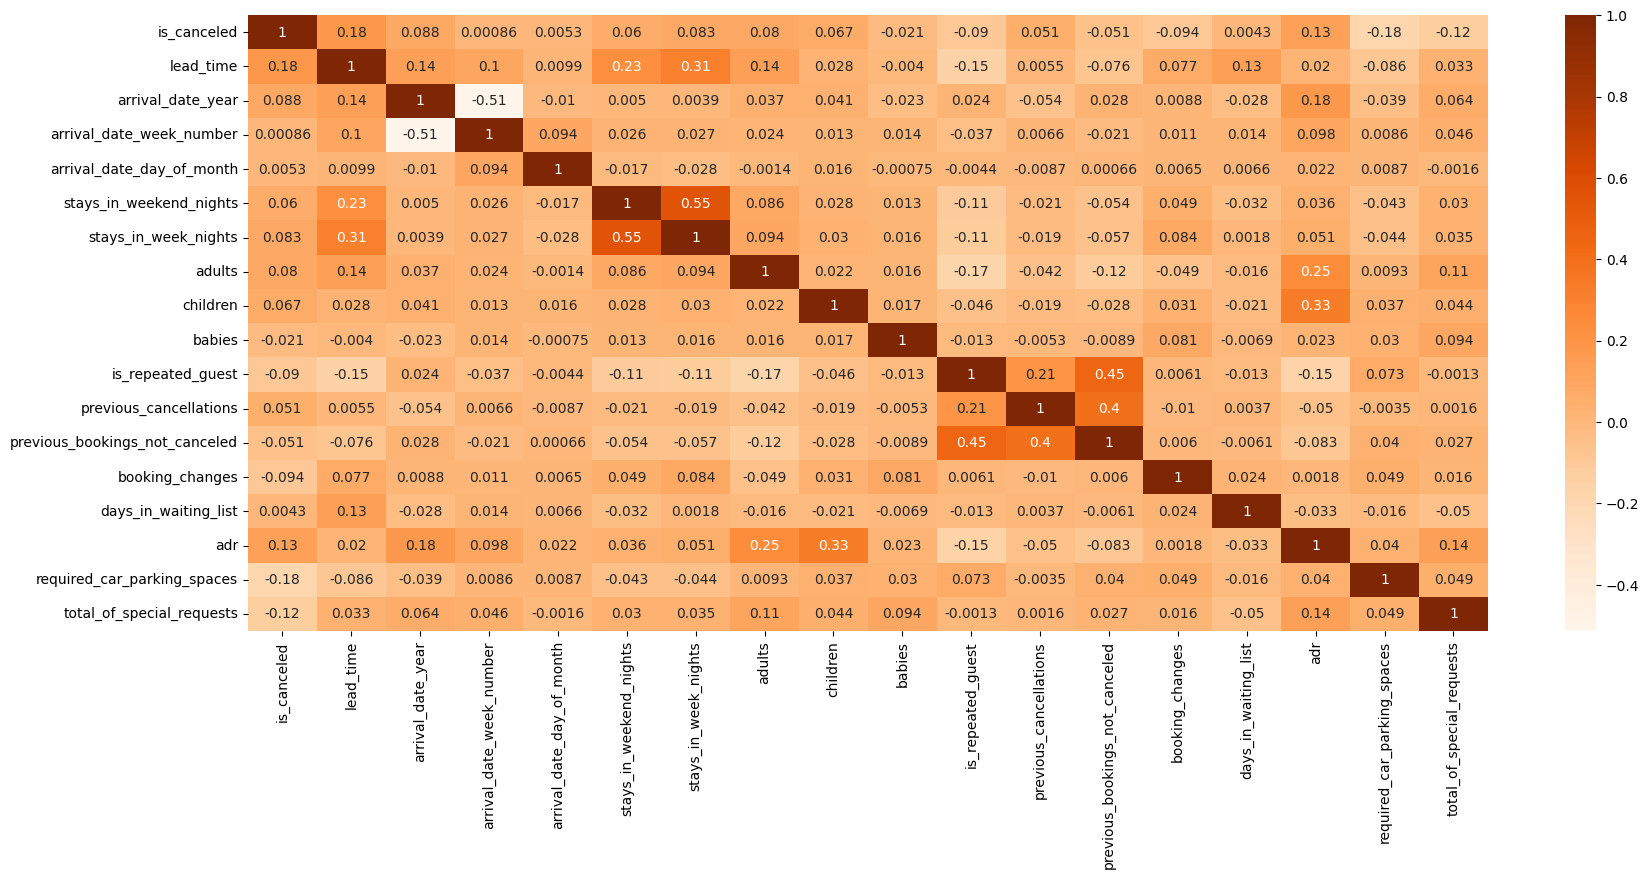

In [19]:
plt.figure(figsize=(20, 8))
hmp = df.drop(columns=['agent', 'company']).corr(numeric_only=True)
sns.heatmap(hmp, cmap='Oranges', annot=True)
plt.show()

In [20]:
target_corr = (
    df.drop(columns=['agent', 'company'])
      .select_dtypes(include='number')
      .corr()['is_canceled']
      .drop('is_canceled')
      .sort_values(key=abs, ascending=False)
)

print(target_corr)

lead_time                         0.183730
required_car_parking_spaces      -0.183704
adr                               0.126675
total_of_special_requests        -0.121794
booking_changes                  -0.094050
is_repeated_guest                -0.090145
arrival_date_year                 0.087665
stays_in_week_nights              0.082818
adults                            0.080295
children                          0.067027
stays_in_weekend_nights           0.059599
previous_cancellations            0.050965
previous_bookings_not_canceled   -0.050553
babies                           -0.020593
arrival_date_day_of_month         0.005281
days_in_waiting_list              0.004302
arrival_date_week_number          0.000864
Name: is_canceled, dtype: float64


'agent' and 'company' were excluded because they are ID codes, so their numeric correlations are not meaningful.

# Vizualizations of Categorical Features vs Cancellation Rate

Categorical columns to analyze:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'booking_history']


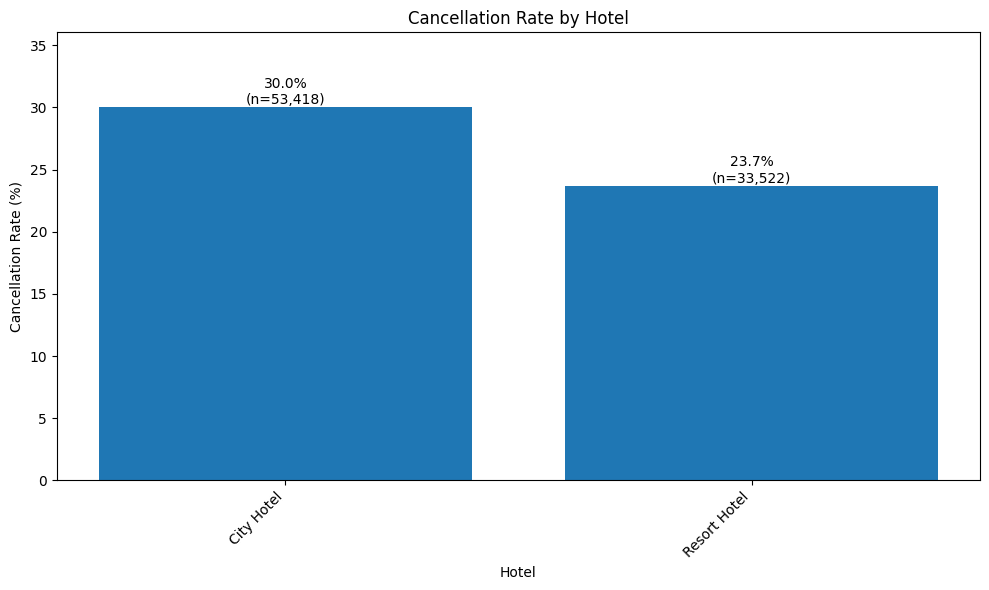

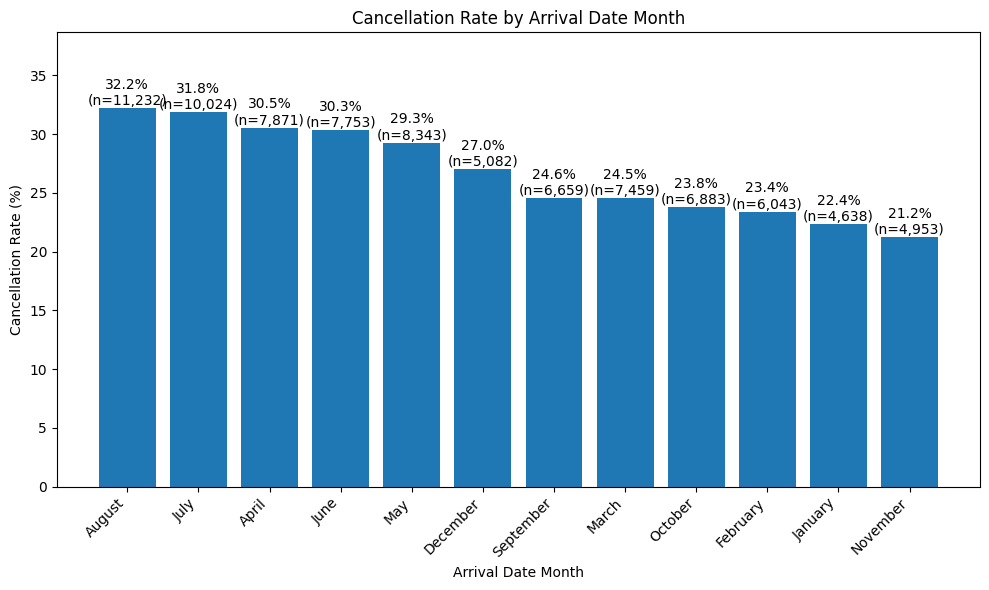

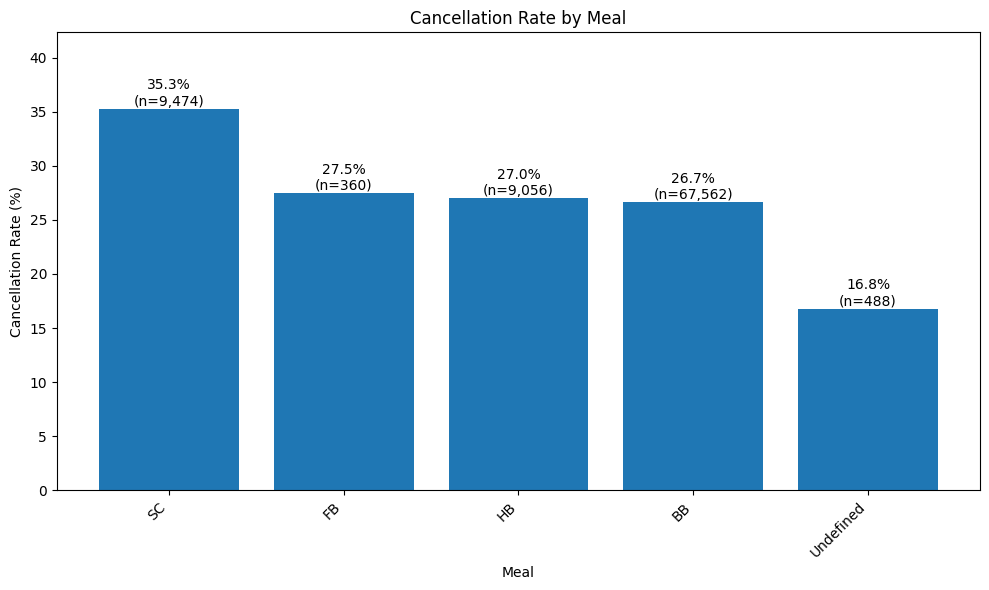

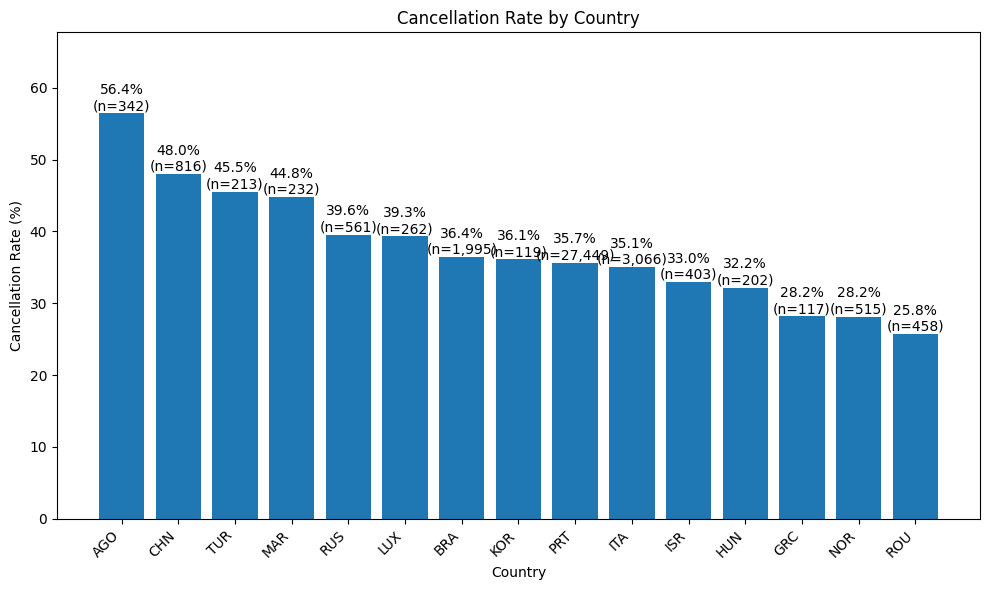

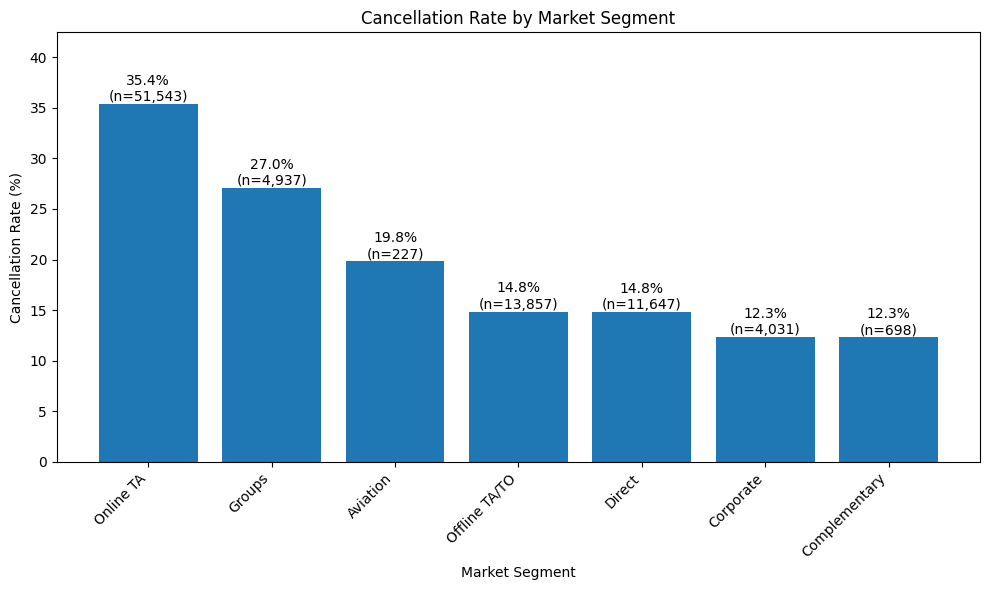

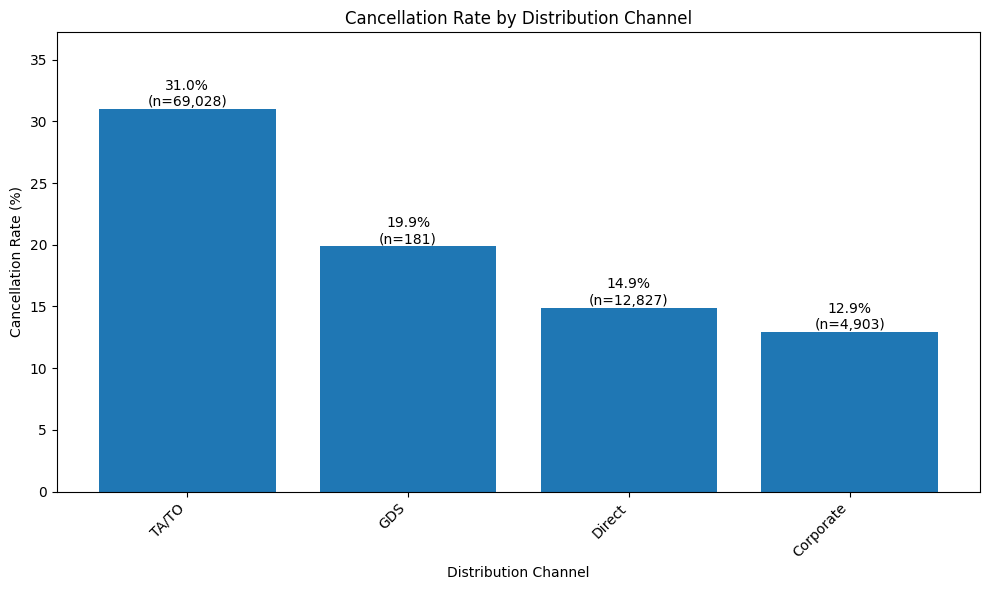

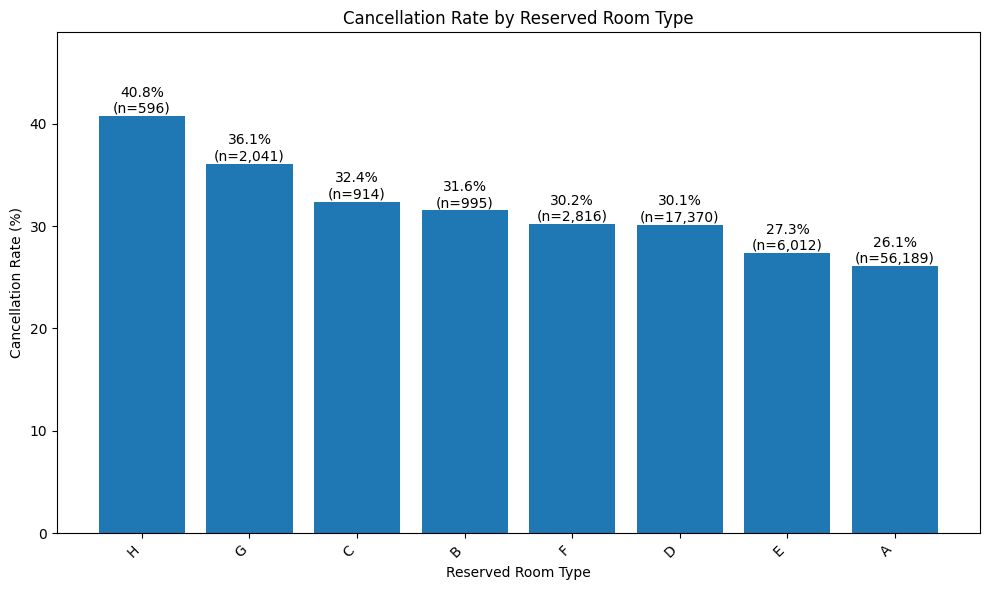

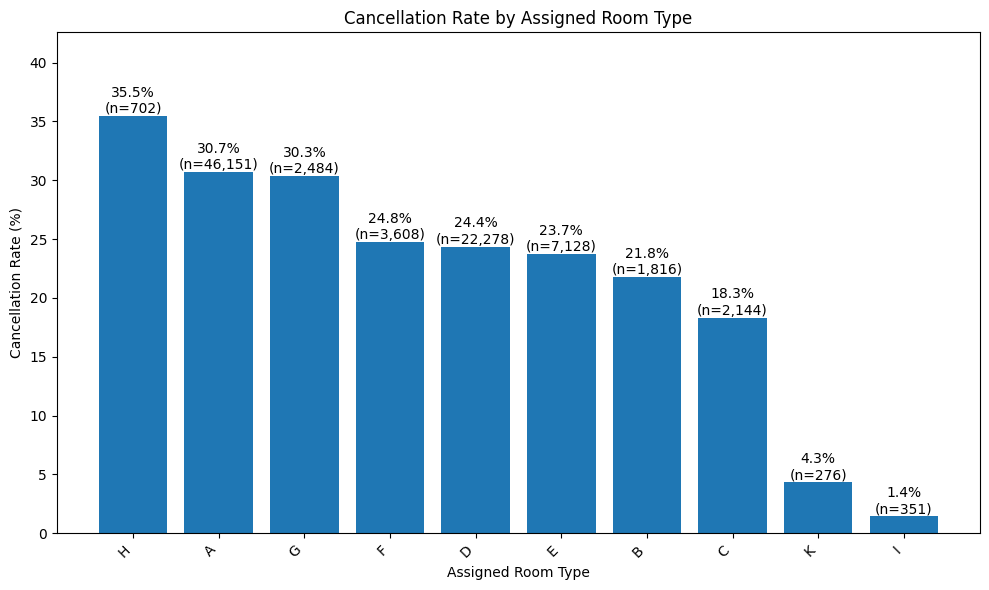

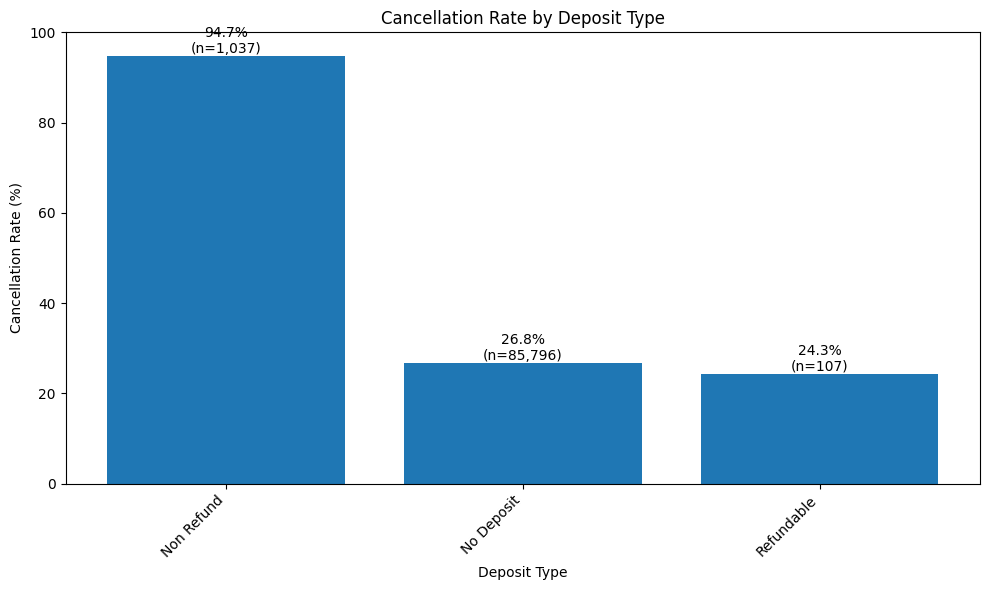

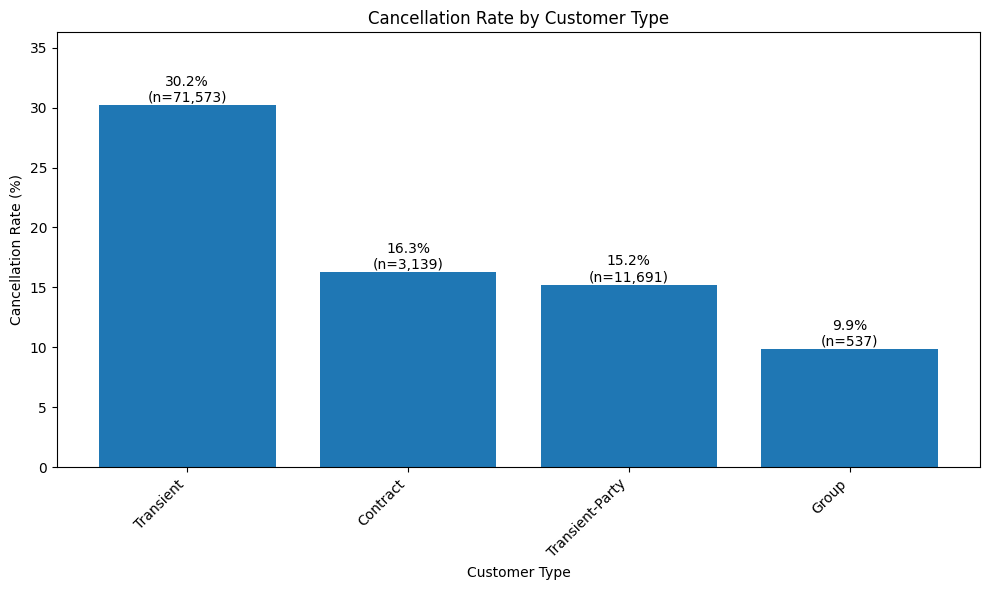

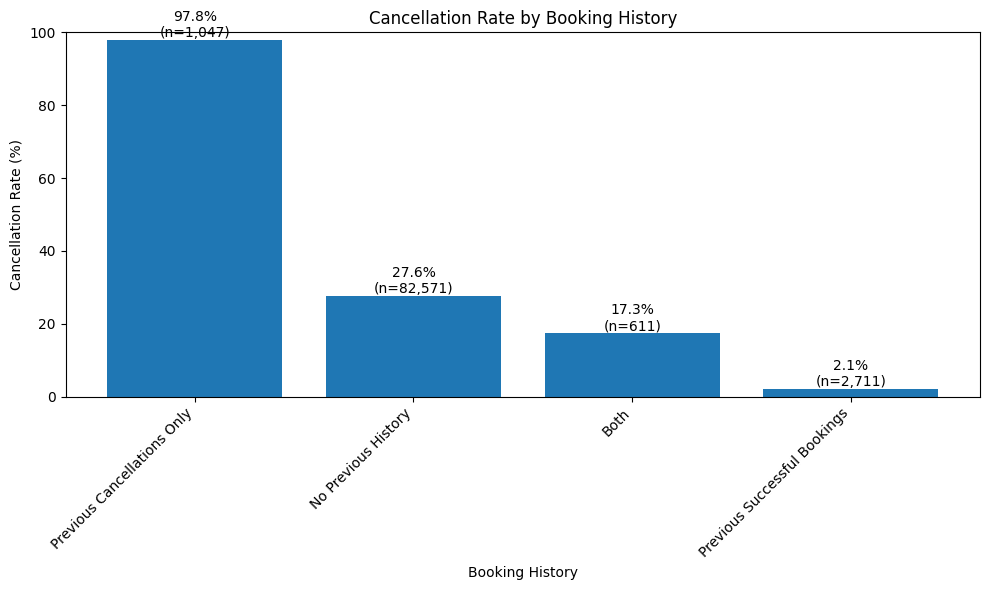

In [21]:
# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns.tolist()

# Remove columns that can cause target leakage
exclude_columns = [
    'reservation_status',
    'reservation_status_date'
]

categorical_columns = [
    col for col in categorical_columns
    if col not in exclude_columns
]

print("Categorical columns to analyze:")
print(categorical_columns)


def plot_cancellation_rate_by_category(
    df,
    column,
    min_count=100,
    max_categories=15
):
    counts = df[column].value_counts()

    valid_categories = counts[counts >= min_count].index

    rates = (
        df[df[column].isin(valid_categories)]
        .groupby(column)['is_canceled']
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .head(max_categories)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        rates.index.astype(str),
        rates.values
    )

    plt.title(
        f'Cancellation Rate by {column.replace("_", " ").title()}'
    )
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Cancellation Rate (%)')

    plt.xticks(rotation=45, ha='right')

    # Label each bar with the rate and the number of bookings
    for bar, rate, category in zip(bars, rates.values, rates.index):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{rate:.1f}%\n(n={counts[category]:,})',
            ha='center',
            va='bottom'
        )

    plt.ylim(0, min(100, rates.max() * 1.2))

    plt.tight_layout()
    plt.show()
# Create a chart for every categorical column
for column in categorical_columns:
    plot_cancellation_rate_by_category(df, column)


Only categories with at least 100 bookings are shown (up to 15 per feature), and each bar is labelled with its booking count (n) so that rates based on small groups can be interpreted with caution.

# Visualizations for numerical features organized into ranges

In [ ]:
def plot_cancellation_rate_by_range(df, column, bins, labels=None):

    # Create ranges
    range_col = f'{column}_range'

    df_temp = df.copy()

    df_temp[range_col] = pd.cut(
        df_temp[column],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    # Calculate cancellation rate
    rates = (
        df_temp.groupby(range_col, observed=True)['is_canceled']
        .mean()
        .mul(100)
    )

    # Plot
    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        rates.index.astype(str),
        rates.values
    )

    plt.title(
        f'Cancellation Rate by {column.replace("_", " ").title()} Range'
    )
    plt.xlabel(
        f'{column.replace("_", " ").title()} Range'
    )
    plt.ylabel('Cancellation Rate (%)')

    plt.xticks(rotation=45, ha='right')

    # Percentage labels
    for bar, rate in zip(bars, rates.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{rate:.1f}%',
            ha='center',
            va='bottom'
        )

    plt.ylim(0, min(100, rates.max() * 1.15))

    plt.tight_layout()
    plt.show()

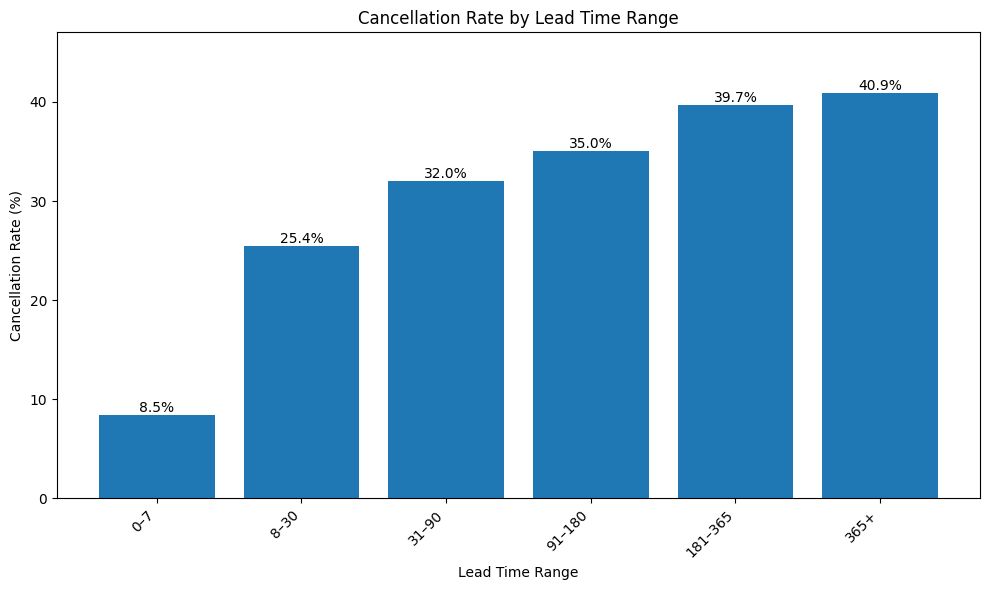

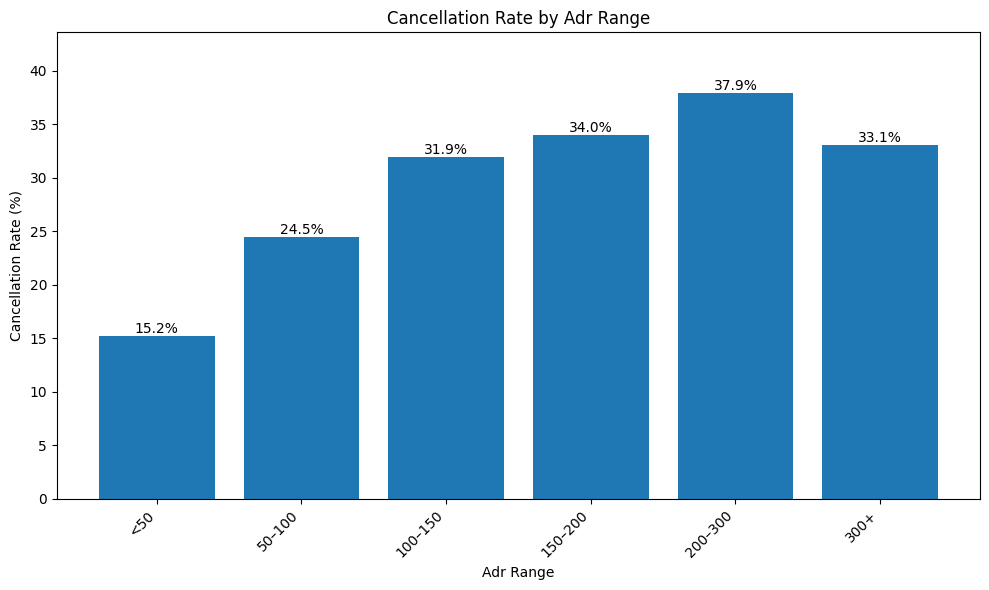

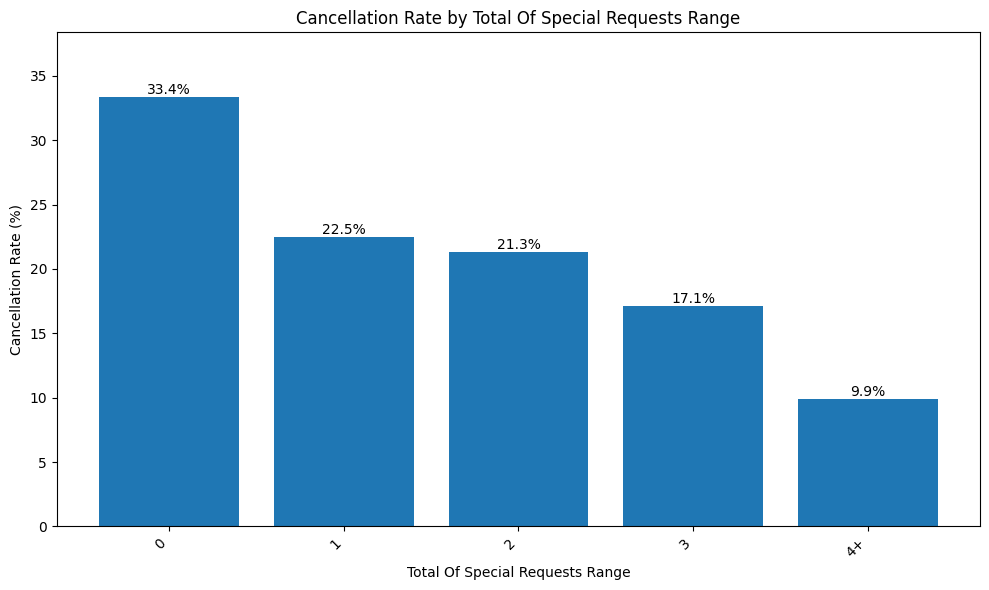

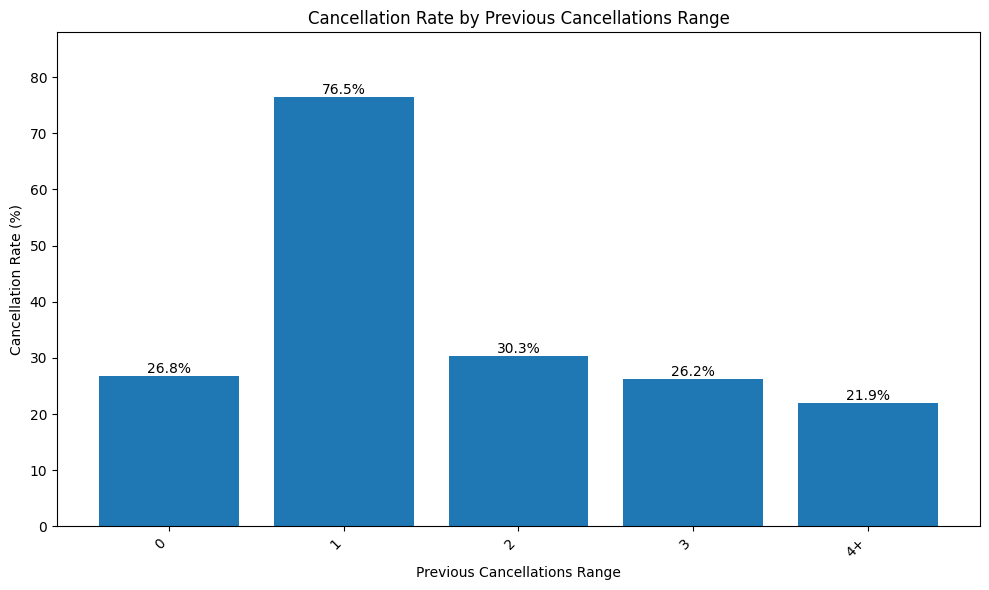

In [ ]:
# Lead time
plot_cancellation_rate_by_range(
    df, 'lead_time',
    [0, 7, 30, 90, 180, 365, float('inf')],
    ['0–7', '8–30', '31–90', '91–180', '181–365', '365+']
)

# ADR
plot_cancellation_rate_by_range(
    df, 'adr',
    [0, 50, 100, 150, 200, 300, float('inf')],
    ['<50', '50–100', '100–150', '150–200', '200–300', '300+']
)

# Total special requests
plot_cancellation_rate_by_range(
    df, 'total_of_special_requests',
    [-1, 0, 1, 2, 3, float('inf')],
    ['0', '1', '2', '3', '4+']
)

# Previous cancellations
plot_cancellation_rate_by_range(
    df, 'previous_cancellations',
    [-1, 0, 1, 2, 3, float('inf')],
    ['0', '1', '2', '3', '4+']
)

# Relationship between cancellation rate, arrival month and hotel type

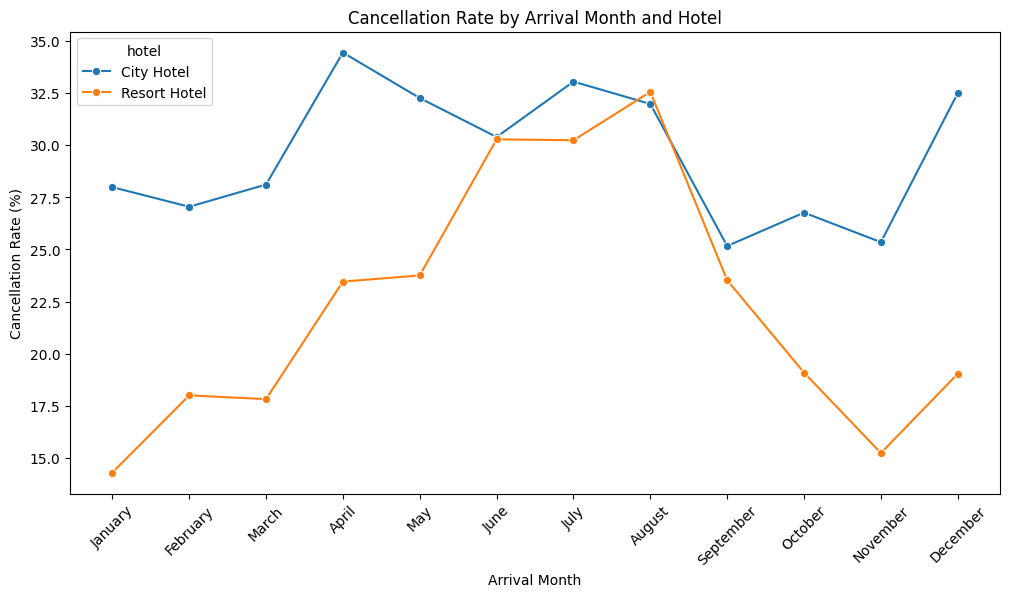

In [ ]:
monthly_hotel = (
    df.groupby(
        ['arrival_date_month', 'hotel'],
        observed=True
    )['is_canceled']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_hotel,
    x='arrival_date_month',
    y='is_canceled',
    hue='hotel',
    marker='o'
)

plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Arrival Month')
plt.title('Cancellation Rate by Arrival Month and Hotel')
plt.xticks(rotation=45)
plt.show()

# Lead Time Distribution by Cancellation Status

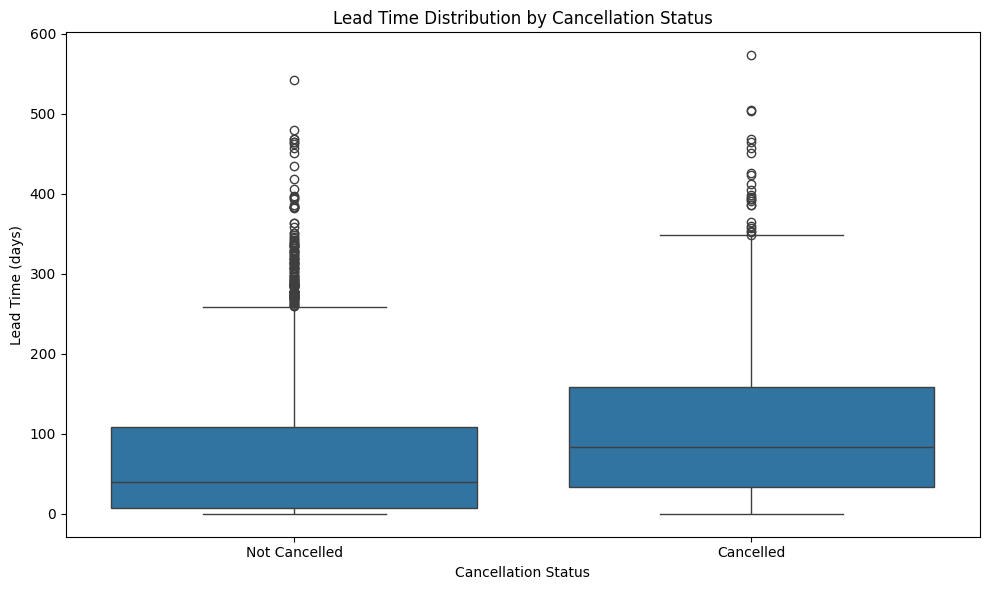

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df.sample(5000, random_state=42),
    x='is_canceled',
    y='lead_time')

plt.xlabel('Cancellation Status')
plt.ylabel('Lead Time (days)')
plt.title('Lead Time Distribution by Cancellation Status')

plt.xticks(
    [0, 1],
    ['Not Cancelled', 'Cancelled']
)

plt.tight_layout()
plt.show()

# Investigation of Target Leakage in Reservation Status

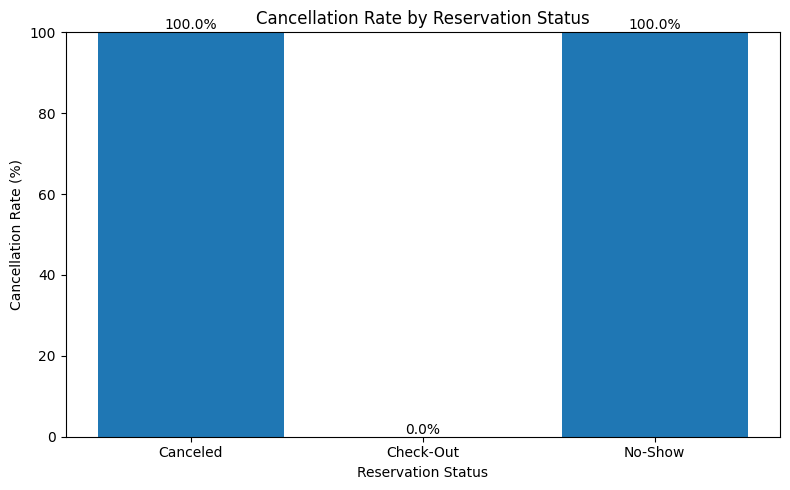

In [ ]:
status_rate = (
    df.groupby('reservation_status')['is_canceled']
      .mean()
      .mul(100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    status_rate.index,
    status_rate.values
)

plt.xlabel('Reservation Status')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Reservation Status')

for bar, rate in zip(bars, status_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{rate:.1f}%',
        ha='center',
        va='bottom'
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Conclusion: Reseravation Status causes leakage

# 'previous_cancellations' vs 'previous_bookings_not_cancelled'

In [14]:
print(
    df['previous_cancellations']
      .corr(df['previous_bookings_not_canceled'])
)

0.3958888147048902


In [15]:
def booking_history(row):
    if row['previous_cancellations'] == 0 and row['previous_bookings_not_canceled'] == 0:
        return 'No Previous History'
    elif row['previous_cancellations'] > 0 and row['previous_bookings_not_canceled'] == 0:
        return 'Previous Cancellations Only'
    elif row['previous_cancellations'] == 0 and row['previous_bookings_not_canceled'] > 0:
        return 'Previous Successful Bookings'
    else:
        return 'Both'

df['booking_history'] = df.apply(booking_history, axis=1)

In [16]:
history_rate = (
    df.groupby('booking_history')['is_canceled']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(history_rate)

booking_history
Previous Cancellations Only     97.803247
No Previous History             27.611389
Both                            17.348609
Previous Successful Bookings     2.139432
Name: is_canceled, dtype: float64


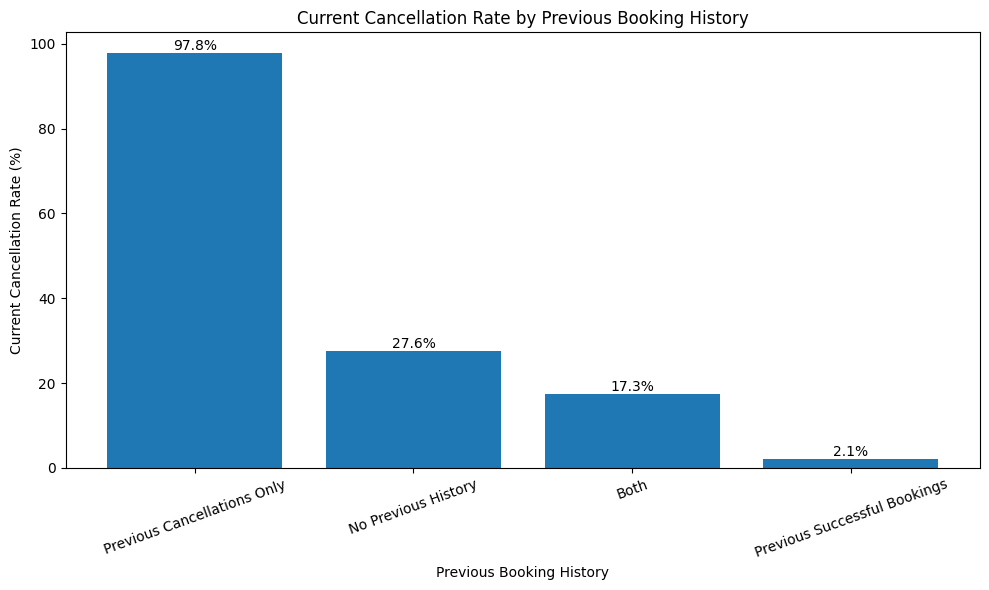

In [17]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    history_rate.index,
    history_rate.values
)

plt.ylabel('Current Cancellation Rate (%)')
plt.xlabel('Previous Booking History')
plt.title('Current Cancellation Rate by Previous Booking History')

plt.xticks(rotation=20)

for bar, rate in zip(bars, history_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{rate:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Interpretation: Previous booking history showed a strong association with current booking cancellation. Customers with previous cancellations but no successful previous bookings had an extremely high current cancellation rate of 97.8%, while customers with previous successful bookings but no previous cancellations had a cancellation rate of only 2.1%. Customers with no previous booking history had a cancellation rate of 27.6%, while those with both previous cancellations and successful bookings had a rate of 17.3%. This suggests that previous customer booking behaviour is an important indicator of future cancellation risk.


In [ ]:
df.groupby('booking_history')['is_canceled'].agg(
    bookings='count',
    cancellations='sum',
    cancellation_rate='mean'
)

,bookings,cancellations,cancellation_rate
booking_history,,,
Both,611,106,0.173486
No Previous History,82571,22799,0.276114
Previous Cancellations Only,1047,1024,0.978032
Previous Successful Bookings,2711,58,0.021394


Conclusion: The 97.8% and 2.1% rates are not based on small groups.

# Statistical Check: Categorical Features vs Cancellation

In [18]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

categorical_columns = df.select_dtypes(include='object').columns.tolist()
exclude_columns = ['reservation_status', 'reservation_status_date']
categorical_columns = [col for col in categorical_columns if col not in exclude_columns]

def cramers_v(col):
    table = pd.crosstab(df[col], df['is_canceled'])
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

cv = pd.Series(
    {col: cramers_v(col) for col in categorical_columns + ['booking_history']}
).sort_values(ascending=False)

print(cv.round(3))

market_segment          0.220
booking_history         0.200
country                 0.195
deposit_type            0.165
distribution_channel    0.151
customer_type           0.128
assigned_room_type      0.094
arrival_date_month      0.084
hotel                   0.069
meal                    0.062
reserved_room_type      0.056
dtype: float64


Interpretation: Cramér's V ranges from 0 (no association) to 1 (perfect association). Features near the top are the strongest categorical predictors; features near 0 are candidates to drop or group.

# Interaction: Lead Time and Hotel Type

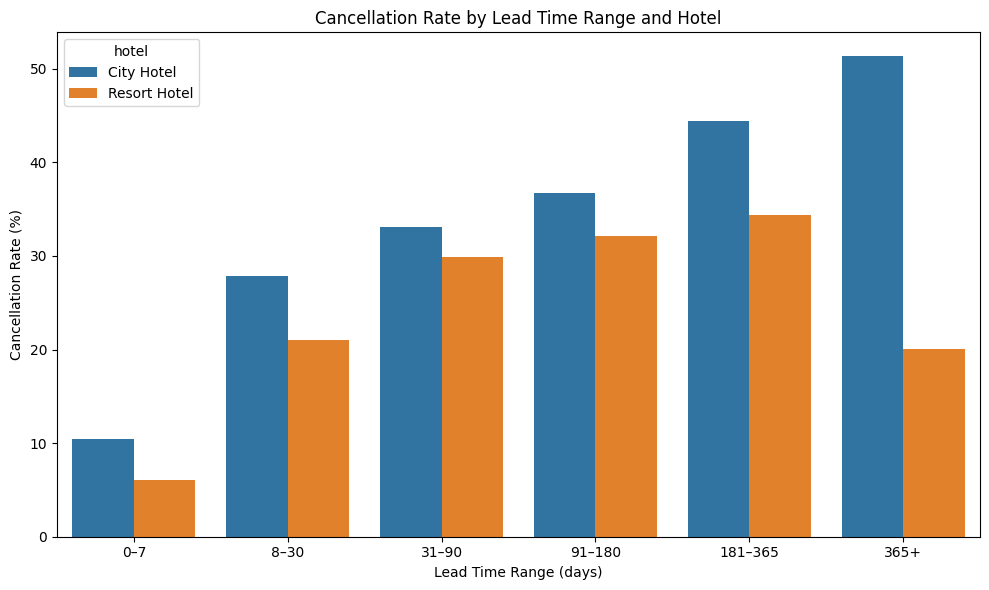

In [11]:
lead_range = pd.cut(
    df['lead_time'],
    [0, 7, 30, 90, 180, 365, float('inf')],
    labels=['0–7', '8–30', '31–90', '91–180', '181–365', '365+'],
    include_lowest=True
)

lead_hotel = (
    df.groupby([lead_range, 'hotel'], observed=True)['is_canceled']
      .mean()
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=lead_hotel, x='lead_time', y='is_canceled', hue='hotel')
plt.xlabel('Lead Time Range (days)')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Lead Time Range and Hotel')
plt.tight_layout()
plt.show()

Interpretation: Cancellation rate generally rises with lead time in both hotels. Bookings made within a week of arrival have the lowest rates (about 10% for City Hotel and 6% for Resort Hotel), while longer lead times are cancelled far more often. City Hotel has a higher cancellation rate than Resort Hotel in every range, and the gap widens at longer lead times. The hotels diverge most in the 365+ range: City Hotel cancellations keep climbing to about 51%, whereas Resort Hotel cancellations fall to about 20%. This suggests the effect of lead time depends on the hotel type, so an interaction between lead_time and hotel may be useful.

# Leakage Check: Room Type Change

In [12]:
room_changed = df['reserved_room_type'] != df['assigned_room_type']

df.groupby(room_changed)['is_canceled'].agg(
    bookings='count',
    cancellation_rate='mean'
)

,bookings,cancellation_rate
False,74047,0.315718
True,12893,0.047235


Bookings where the assigned room differed from the reserved room had a cancellation rate of only 4.7%, compared with 31.6% where the room stayed the same. This large gap suggests that assigned_room_type is likely finalised late in the booking process, around check-in. A guest who cancels never reaches that stage, so a room change effectively signals that the guest showed up. Because this information would not be available at the time a cancellation prediction is made, assigned_room_type is a potential source of target leakage.

In [22]:
num_cols = df.drop(columns=['agent', 'company', 'is_canceled']).select_dtypes(include='number')
corr = num_cols.corr()

# Keep each pair once (upper triangle only)
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()

high_corr = pairs[pairs.abs() > 0.5].sort_values(key=abs, ascending=False)
print(high_corr.round(3))

stays_in_weekend_nights  stays_in_week_nights        0.551
arrival_date_year        arrival_date_week_number   -0.514
dtype: float64


Intepretation: Two pairs of numeric features have a moderate correlation above 0.5. stays_in_weekend_nights and stays_in_week_nights are positively correlated (0.551), which is expected because longer stays naturally include more of both types of night. arrival_date_year and arrival_date_week_number are negatively correlated (-0.514). This is likely an artefact of the data collection period rather than a real relationship: the data starts in the middle of 2015 and ends in the middle of 2017, so 2015 only contains later weeks of the year and 2017 only contains earlier weeks. Neither correlation is strong enough to indicate serious multicollinearity.

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(num_cols.dropna())

vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
    index=num_cols.columns
).sort_values(ascending=False)

print(vif.round(2))

arrival_date_year                 1.59
arrival_date_week_number          1.53
stays_in_week_nights              1.53
stays_in_weekend_nights           1.45
previous_bookings_not_canceled    1.43
adr                               1.34
is_repeated_guest                 1.32
lead_time                         1.27
previous_cancellations            1.20
children                          1.13
adults                            1.13
total_of_special_requests         1.05
days_in_waiting_list              1.03
booking_changes                   1.03
required_car_parking_spaces       1.02
babies                            1.02
arrival_date_day_of_month         1.01
dtype: float64


Intepretation: Variance Inflation Factors (VIF) were calculated for all numeric features. All values were below 2 (the highest being arrival_date_year at 1.59), well under the common threshold of 5, which indicates no serious multicollinearity among the numeric features. The moderate pairwise correlations identified earlier (the stay-night columns and the arrival year/week number pair) do not translate into problematic redundancy when all features are considered together.

# Summary of Findings for Feature Engineering

| Feature | Finding | Action |
|---|---|---|
| `reservation_status`, `reservation_status_date` | Directly reveals the outcome (target leakage) | Drop |
| `assigned_room_type` | Room-changed bookings cancel at only 4.7% vs 31.6% otherwise, likely because the room is assigned near check-in | Drop (potential leakage) |
| `previous_cancellations`, `previous_bookings_not_canceled` | Weak linear correlation (~0.05), but the combined history groups range from 2.1% to 97.8% cancellation. The engineered `booking_history` has the second strongest categorical association (Cramér's V = 0.200) | Keep, and add `booking_history` as an engineered feature |
| `agent`, `company` | ID codes, so their numeric correlations are meaningless | Treat as categorical, not numeric |
| `lead_time` | Strongest numeric correlation with cancellation (0.18). Cancellation rises with lead time, and the pattern differs by hotel (City keeps rising to ~51% at 365+, Resort falls to ~20%) | Keep, bin, and consider a `lead_time` × `hotel` interaction |
| `arrival_date_month` | Seasonal pattern differs by hotel (Cramér's V = 0.084) | Keep, and consider a hotel × month interaction |
| `market_segment`, `country`, `deposit_type` | Strongest categorical associations with cancellation (Cramér's V = 0.220, 0.195 and 0.165) | Keep. Group rare countries into "Other" |
| `distribution_channel` | Moderate association (V = 0.151) but overlaps with `market_segment` | Keep, but check redundancy with `market_segment` |
| `customer_type` | Weaker but still relevant association (V = 0.128) | Keep |
| `hotel`, `meal`, `reserved_room_type` | Weak individual associations (V = 0.069, 0.062, 0.056) | Keep as low priority. `hotel` is still useful in interactions, and `reserved_room_type` is known at booking time |
| `stays_in_weekend_nights`, `stays_in_week_nights` | Moderately correlated (0.551), since longer stays include both | Optionally combine into `total_nights` |
| `arrival_date_week_number`, `arrival_date_year` | Moderately correlated (-0.514), likely due to the data's date range. Week number overlaps with month and has near-zero correlation with cancellation | Drop `arrival_date_week_number` (keep month). Treat `arrival_date_year` with caution or use it for a time-based split |
| All numeric features | VIF below 2 for every feature (max 1.59), so no serious multicollinearity | No features need removal for multicollinearity |

The bivariate analysis shows that cancellation is driven mainly by booking behaviour and booking type rather than by stay characteristics. Market segment, previous booking history, country and deposit type have the strongest associations with cancellation, and lead time is the strongest numeric predictor, with longer lead times leading to more cancellations, especially at City Hotel. Previous booking history is a particularly useful signal: although its linear correlation is weak, grouping customers by their past behaviour produced cancellation rates ranging from 2.1% to 97.8%, which justified the engineered booking_history feature. Two features, reservation_status and assigned_room_type, leak information about the outcome and should be excluded from modelling. Multicollinearity among the numeric features is low (all VIF values below 2), so the main preprocessing steps are removing the leaking features, handling country (grouping rare values) and the agent and company ID codes as categorical, and considering interaction features such as lead time × hotel.